<a href="https://colab.research.google.com/github/KuChoiLab/2026_bomun_workshop/blob/main/scRNA_seq_hands_on_exercise_script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environment setting

In [1]:
import gdown

file_id = "1Uu0PH3VgX5iR8UsCYt0y1S3lm9vhHLEv"
output = "packageset.tar"
gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1Uu0PH3VgX5iR8UsCYt0y1S3lm9vhHLEv
From (redirected): https://drive.google.com/uc?id=1Uu0PH3VgX5iR8UsCYt0y1S3lm9vhHLEv&confirm=t&uuid=1dad6a97-71c7-4fdc-8c18-9685b95330e3
To: /content/packageset.tar
100%|██████████| 1.39G/1.39G [00:10<00:00, 128MB/s]


'packageset.tar'

In [2]:
!tar -xvf packageset.tar

Streaming output truncated to the last 5000 lines.
content/drive/MyDrive/R_libs/assorthead/include/ritsuko/hdf5/Stream1dStringDataset.hpp
content/drive/MyDrive/R_libs/assorthead/include/ritsuko/hdf5/as_numeric_datatype.hpp
content/drive/MyDrive/R_libs/assorthead/include/ritsuko/hdf5/exceeds_limit.hpp
content/drive/MyDrive/R_libs/assorthead/include/ritsuko/hdf5/get_1d_length.hpp
content/drive/MyDrive/R_libs/assorthead/include/ritsuko/hdf5/get_dimensions.hpp
content/drive/MyDrive/R_libs/assorthead/include/ritsuko/hdf5/get_name.hpp
content/drive/MyDrive/R_libs/assorthead/include/ritsuko/hdf5/hdf5.hpp
content/drive/MyDrive/R_libs/assorthead/include/ritsuko/hdf5/is_utf8_string.hpp
content/drive/MyDrive/R_libs/assorthead/include/ritsuko/hdf5/load_attribute.hpp
content/drive/MyDrive/R_libs/assorthead/include/ritsuko/hdf5/load_dataset.hpp
content/drive/MyDrive/R_libs/assorthead/include/ritsuko/hdf5/miscellaneous.hpp
content/drive/MyDrive/R_libs/assorthead/include/ritsuko/hdf5/missing_placehold

In [3]:
!pip install -q rpy2
%load_ext rpy2.ipython

In [4]:
%%R

.libPaths("/content/content/drive/MyDrive/R_libs")

Loading necessary library and data

In [5]:
#1-1. Loading necessary packages and practice data (< 1min)
%%R
library(Seurat)
library(scDblFinder)
library(SingleCellExperiment)
library(dplyr)
library(ggplot2)
library(patchwork)
library(EnhancedVolcano)
library(msigdbr)
library(clusterProfiler)


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

Loading required package: SeuratObject
Loading required package: sp

Attaching package: ‘SeuratObject’

The following objects are masked from ‘package:base’:

    intersect, t

Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts,

In [6]:
#1-1. Loading practice data (< 1min)
%%R
setwd("/content/content/drive/MyDrive/R_libs")
hs09 <- readRDS("hs09.rds")
hs12 <- readRDS("hs12.rds")
hs13 <- readRDS("hs13.rds")
hs254 <- readRDS("hs254.rds")
hs255 <- readRDS("hs255.rds")
hs266 <- readRDS("hs266.rds")

Removing doublets

In [7]:
#2-1. Convert your Seurat objects to SingleCellExperiment (< 1min)
%%R
sce09 <- as.SingleCellExperiment(hs09, assay = "RNA")
sce12 <- as.SingleCellExperiment(hs12, assay = "RNA")
sce13 <- as.SingleCellExperiment(hs13, assay = "RNA")
sce254 <- as.SingleCellExperiment(hs254, assay = "RNA")
sce255 <- as.SingleCellExperiment(hs255, assay = "RNA")
sce266 <- as.SingleCellExperiment(hs266, assay = "RNA")

In addition: There were 12 warnings (use warnings() to see them)


In [8]:
#2-2. Run scDblFinder (~10min)
%%R
sce09 <- scDblFinder(sce09)
sce12 <- scDblFinder(sce12)
sce13 <- scDblFinder(sce13)
sce254 <- scDblFinder(sce254)
sce255 <- scDblFinder(sce255)
sce266 <- scDblFinder(sce266)
gc()

            used   (Mb) gc trigger   (Mb)  max used   (Mb)
Ncells  12517479  668.6   19357354 1033.8  19170859 1023.9
Vcells 392536980 2994.9  701236230 5350.1 701235834 5350.1


Creating ~6084 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1129 cells excluded from training.
iter=1, 1265 cells excluded from training.
iter=2, 1270 cells excluded from training.
Threshold found:0.685
841 (11.1%) doublets called
Creating ~11340 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2653 cells excluded from training.
iter=1, 2549 cells excluded from training.
iter=2, 2268 cells excluded from training.
Threshold found:0.435
1714 (12.1%) doublets called
Creating ~8980 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1988 cells excluded from training.
iter=1, 2002 cells excluded from training.
iter=2, 1983 cells excluded from training.
Threshold found:0.514
1349 (12%) doublets called
Creating ~13800 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 3659 cells excluded from training.
iter=1, 3722 cells excluded from t

In [9]:
#2-3. Add the results back to your Seurat object (< 1min)
%%R
hs09$doublet_score <- sce09$scDblFinder.score
hs09$is_doublet <- sce09$scDblFinder.class

hs12$doublet_score <- sce12$scDblFinder.score
hs12$is_doublet <- sce12$scDblFinder.class

hs13$doublet_score <- sce13$scDblFinder.score
hs13$is_doublet <- sce13$scDblFinder.class

hs254$doublet_score <- sce254$scDblFinder.score
hs254$is_doublet <- sce254$scDblFinder.class

hs255$doublet_score <- sce255$scDblFinder.score
hs255$is_doublet <- sce255$scDblFinder.class

hs266$doublet_score <- sce266$scDblFinder.score
hs266$is_doublet <- sce266$scDblFinder.class

In [16]:
#2-4. Check how many cells were detected as doublets (< 1min)
%%R
print("hs09")
print(table(hs09$is_doublet))
print("hs12")
print(table(hs12$is_doublet))
print("hs13")
print(table(hs13$is_doublet))
print("hs254")
print(table(hs254$is_doublet))
print("hs255")
print(table(hs255$is_doublet))
print("hs266")
print(table(hs266$is_doublet))

[1] "hs09"

singlet doublet 
   6782     822 
[1] "hs12"

singlet doublet 
  12422    1752 
[1] "hs13"

singlet doublet 
   9799    1426 
[1] "hs254"

singlet doublet 
  14452    2797 
[1] "hs255"

singlet doublet 
   7464    1005 
[1] "hs266"

singlet doublet 
   6785     832 


In [10]:
#2-5. Filtering doublet cells (< 1min)
%%R
hs09 <- subset(hs09, subset = is_doublet == "singlet")
hs12 <- subset(hs12, subset = is_doublet == "singlet")
hs13 <- subset(hs13, subset = is_doublet == "singlet")
hs254 <- subset(hs254, subset = is_doublet == "singlet")
hs255 <- subset(hs255, subset = is_doublet == "singlet")
hs266 <- subset(hs266, subset = is_doublet == "singlet")

In [12]:
#2-6. Merge separate datas into one for convenience in further analysis (< 1min)
%%R
data <- merge(
  x = hs09,
  y = c(hs12, hs13, hs254, hs255, hs266),
  add.cell.ids = c("Hs09", "Hs12", "Hs13", "Hs254", "Hs255", "Hs266"),
)

set.seed(42)

cells_to_keep <- sample(colnames(data), size = 6000)
data <- subset(data, cells = cells_to_keep)

Quality Control

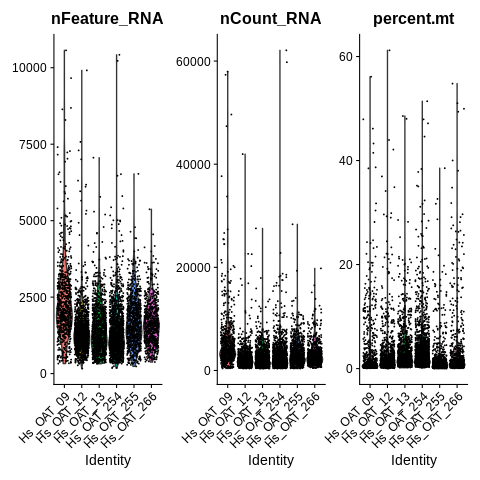

In [15]:
#3-1. Take a look at nFeature, nCount, percent.mt metrics within our data (< 1min)
%%R
VlnPlot(data, group.by = 'sample',feature = c("nFeature_RNA","nCount_RNA","percent.mt"),ncol=3)

In [16]:
#3-2. Filtering cells with high mitochondrial percentage (< 1min)
%%R
data <- subset(data, subset = percent.mt < 20 & nCount_RNA >= 200)

Normalization

In [17]:
#4. Normalization (< 1min)
%%R
data <- NormalizeData(data, normalization.method = "LogNormalize", scale.factor = 10000)
gc()

            used   (Mb) gc trigger   (Mb)  max used   (Mb)
Ncells  12810464  684.2   19357354 1033.8  19357354 1033.8
Vcells 382267944 2916.5  701236230 5350.1 701235834 5350.1


Normalizing layer: counts.1
Performing log-normalization
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Normalizing layer: counts.2
Performing log-normalization
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Normalizing layer: counts.3
Performing log-normalization
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Normalizing layer: counts.4
Performing log-normalization
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Normalizing layer: counts.5
Performing log-normalization
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|---

Feature selection

In [18]:
#5-1. Finding variable features (< 1min)
%%R
data <- FindVariableFeatures(data, selection.method = "vst", nfeatures = 2000)
gc()

            used   (Mb) gc trigger   (Mb)  max used   (Mb)
Ncells  12821328  684.8   19357354 1033.8  19357354 1033.8
Vcells 383176007 2923.5  701236230 5350.1 701235834 5350.1


Finding variable features for layer counts.1
Calculating gene variances
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Calculating feature variances of standardized and clipped values
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Finding variable features for layer counts.2
Calculating gene variances
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Calculating feature variances of standardized and clipped values
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Finding variable features for layer counts.3
Calculating gene variances
0%   10   20   30 



(`geom_point()`). 



When using repel, set xnudge and ynudge to 0 for optimal results


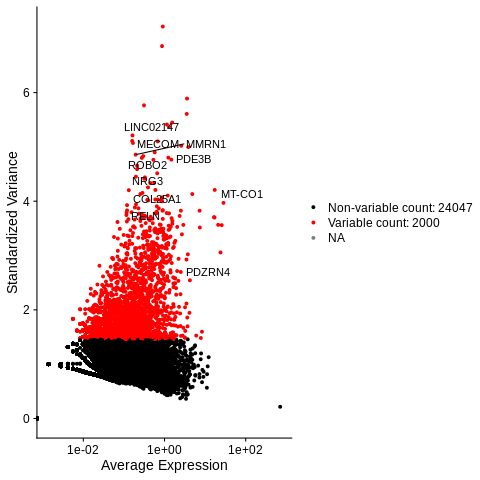

In [19]:
#5-2.Checking variable features (< 1min)
%%R
top10 <- head(VariableFeatures(data), 10)
plot1 <- VariableFeaturePlot(data)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
plot2

Scaling

In [20]:
#6. Scaling (< 1min)
%%R
data <- ScaleData(data)

Centering and scaling data matrix
  |======================================================================| 100%


Linear dimension reduction(PCA)

In [21]:
#7-1. Run PCA (< 1min)
%%R
set.seed(42)
data <- RunPCA(data, verbose = FALSE)

            used   (Mb) gc trigger   (Mb)  max used   (Mb)
Ncells  12846427  686.1   19357354 1033.8  19357354 1033.8
Vcells 380844757 2905.7  701236230 5350.1 701235834 5350.1


PC_ 1 
Positive:  PLIN1, TRHDE, SORBS1, KCNIP2-AS1, AQP7 
Negative:  PDE4D, PKHD1L1, PLCB1, AP000561.1, THSD4 
PC_ 2 
Positive:  PKHD1L1, AP000561.1, PLCB1, AC005699.1, SOX6 
Negative:  SYK, TBXAS1, MS4A4E, ADAP2, ATP8B4 
PC_ 3 
Positive:  SOX6, ERBB4, WDPCP, AP000561.1, LINC02360 
Negative:  LDB2, HMCN1, TFPI, ZNF385D, PREX2 
PC_ 4 
Positive:  MECOM, EMCN, PTPRB, ANO2, EGFL7 
Negative:  NEGR1, ABCA10, ABCA9, ABCA6, LAMA2 
PC_ 5 
Positive:  STOX2, RELN, LINC02147, PROX1, RHOJ 
Negative:  MT-ND3, MT-CO3, MT-CYB, MT-ATP6, MT-CO2 


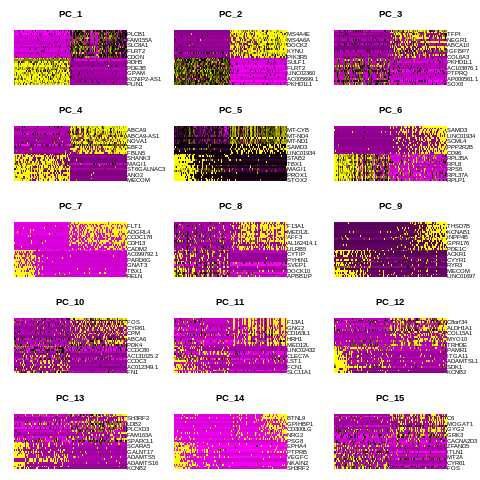

In [22]:
#7-2. Examine and visualize PCA results (< 1min)
%%R
print(data[["pca"]], dims = 1:5, nfeatures = 5)
DimHeatmap(data, dims = 1:15, cells = 500, balanced = TRUE)

In [23]:
#7-3. Elbow plot (Determining # of PCs to use for further analysis) (< 1min)
%%R
stdev <- data[["pca"]]@stdev
pct <- stdev / sum(stdev) * 100
cum_pct <- cumsum(pct)
pcs <- 1:length(stdev)
plot_df <- data.frame(PC = pcs, stdev = stdev, pct = pct, cum_pct = cum_pct)

pc_90 <- which(cum_pct >= 90)[1]
pc_01 <- which(diff(pct) > -0.1)[1]

p_main <- ggplot(plot_df, aes(x = PC, y = stdev)) +
  geom_point(size = 1.5) +
  geom_vline(xintercept = pc_90, color = "royalblue", linetype = "solid") +
  geom_vline(xintercept = pc_01, color = "red", linetype = "dashed") +
  theme_classic() +
  labs(title = "Method for selecting the appropriate number of PCs:\n1) 90% variance (Blue line)\n2) <0.1% drop (Red line)",
       y = "Standard Deviation")

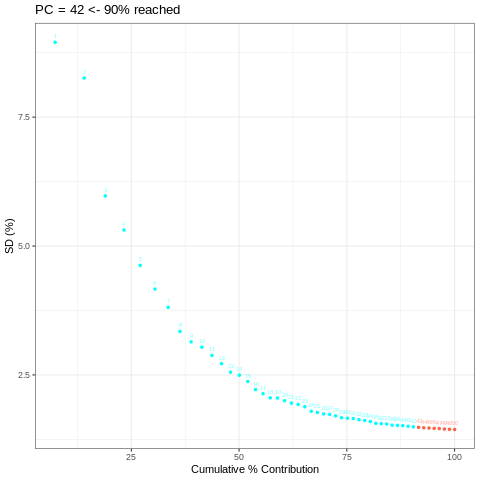

In [24]:
#7-4. Create the Cumulative Contribution Subplots (< 1min)
# Subplot 1: 90% Threshold
%%R
p1 <- ggplot(plot_df, aes(x = cum_pct, y = stdev)) +
  geom_point(aes(color = PC <= pc_90), size = 1) +
  geom_text(aes(label = PC, color = PC <= pc_90), vjust = -1, size = 2, alpha = 0.5) +
  scale_color_manual(values = c("TRUE" = "cyan", "FALSE" = "tomato")) +
  theme_bw() +
  labs(title = paste0("PC = ", pc_90, " <- 90% reached"),
       x = "Cumulative % Contribution", y = "SD (%)") +
  theme(legend.position = "none")
  p1

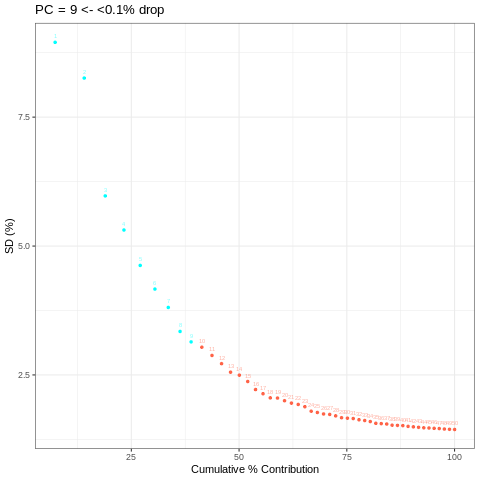

In [25]:
#7-5. Subplot 2: 0.1% Drop Threshold (< 1min)
%%R
p2 <- ggplot(plot_df, aes(x = cum_pct, y = stdev)) +
  geom_point(aes(color = PC <= pc_01), size = 1) +
  geom_text(aes(label = PC, color = PC <= pc_01), vjust = -1, size = 2, alpha = 0.5) +
  scale_color_manual(values = c("TRUE" = "cyan", "FALSE" = "tomato")) +
  theme_bw() +
  labs(title = paste0("PC = ", pc_01, " <- <0.1% drop"),
       x = "Cumulative % Contribution", y = "SD (%)") +
  theme(legend.position = "none")
  p2

Clustering

In [26]:
#8. Clustering the cell (1min)
%%R
data <- FindNeighbors(data, dims = 1:10,reduction='pca',seed.use=42)
data <- FindClusters(data, resolution = 0.1,random.seed=42)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5884
Number of edges: 191791

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9687
Number of communities: 8
Elapsed time: 0 seconds


Computing nearest neighbor graph
Computing SNN
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|


Non-linear dimesionality reduction(UMAP)

In [27]:
#9-1. Run UMAP (1min)
%%R
data <- RunUMAP(data, dims = 1:10)


To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session
04:01:27 UMAP embedding parameters a = 0.9922 b = 1.112
04:01:28 Read 5884 rows and found 10 numeric columns
04:01:28 Using Annoy for neighbor search, n_neighbors = 30
04:01:28 Building Annoy index with metric = cosine, n_trees = 50
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
04:01:28 Writing NN index file to temp file /tmp/Rtmp5AV7sa/file14dc640ea87
04:01:28 Searching Annoy index using 1 thread, search_k = 3000
04:01:31 Annoy recall = 100%
04:01:32 Commencing smooth kNN distance calibration using 1 thread with target n_neighbors = 30
04:01:35 Initializing from normalized Laplacian + noise (using RSpectra)
04:01:35 Commencing optimization for 500 epochs, with 238916 positive edges
04:01:35 Using rng type: pcg
Using method 'umap'
0%   10

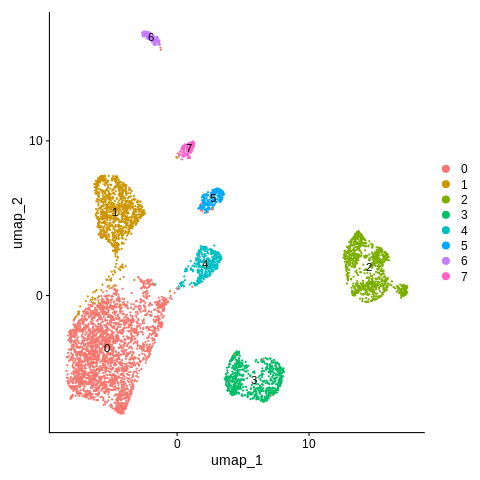

In [28]:
#9-2. Examine our clusters (< 1min)
%%R
DimPlot(data,reduction="umap",label = TRUE)

Annotation

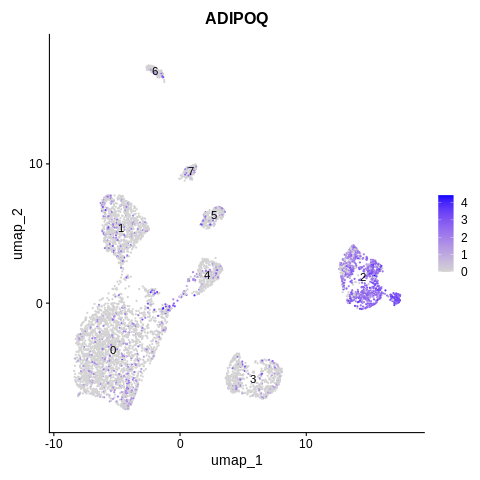

In [29]:
#10-1. Checking for canonical markers (< 1min)
%%R
FeaturePlot(data, features = c("ADIPOQ"),label=TRUE) #Adipocyte cell marker

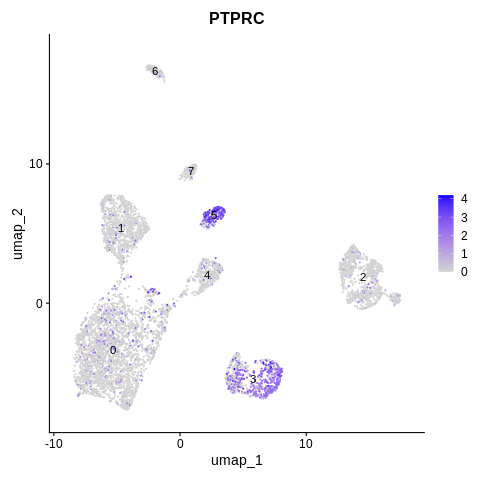

In [30]:
#10-2. Checking for canonical markers (< 1min)
%%R
FeaturePlot(data, features = c("PTPRC"),label=TRUE) #Immune cell marker

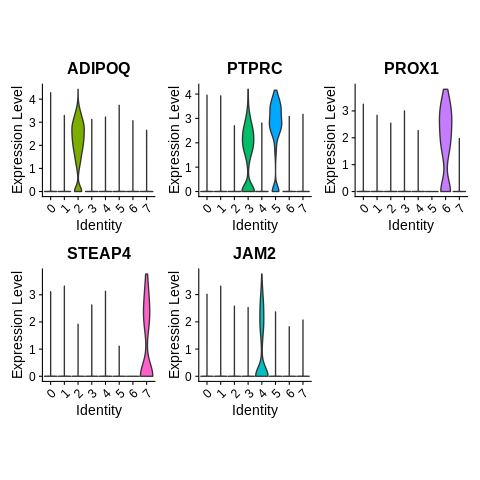

In [31]:
#10-3. Checking canonical marker expression profile in our clusters (< 1min)
%%R
VlnPlot(data, features=c('ADIPOQ','PTPRC','PROX1','STEAP4','JAM2'), group.by='seurat_clusters', pt.size=0) & theme(aspect.ratio=1)


10-4. Finding differentially expressed genes cluster2(presumably adipocyte) vs other clusters

This step was performed ahead of the exercise due to time limit. Please refer to the cluster2marker file.

%%R
data <- JoinLayers(data)

cluster2_markers <- FindMarkers(data, ident.1 = 2)
cluster2_markers %>%
  dplyr::filter(avg_log2FC > 1)

In [33]:
#10-5. Annotation (< 1min)
%%R
new.cluster.ids <- c("Fibroblast", "ASPC", "Adipose cells", "Immunce cells", "Endothelial cells", "Immune cells",
                     "LEC", "Pericyte")
names(new.cluster.ids) <- levels(data)
data <- RenameIdents(data, new.cluster.ids)
data$cell_type <- Idents(data)

Differential abundance analysis between 'normal' vs 'obese'

In [35]:
#11-1. Create a frequency table of cell type vs condition and calculate percentages for each condition (< 1min)
%%R
data$condition <- ifelse(data$bmi <=25,'normal','obese')
counts <- as.data.frame(table(data$cell_type, data$condition))
colnames(counts) <- c("Cell_type", "Condition", "Freq")

counts <- counts %>%
  group_by(Condition) %>%
  mutate(Percentage = (Freq / sum(Freq)) * 100)

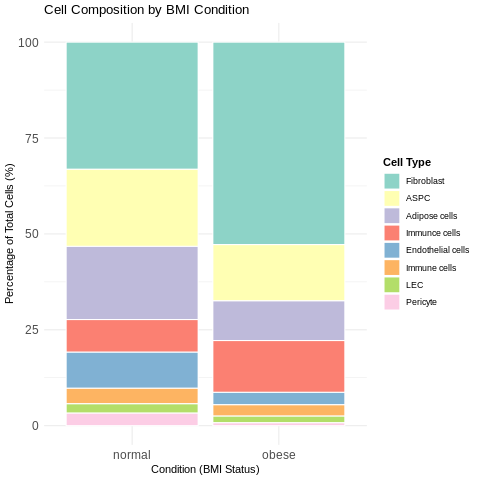

In [37]:
#11-2. Draw the Stacked Barplot (< 1min)
%%R
ggplot(counts, aes(x = Condition, y = Percentage, fill = Cell_type)) +
  geom_bar(stat = "identity", color = "white") +
  theme_minimal() +
  labs(title = "Cell Composition by BMI Condition",
       x = "Condition (BMI Status)",
       y = "Percentage of Total Cells (%)",
       fill = "Cell Type") +
  scale_fill_brewer(palette = "Set3") + # Change palette as needed
  theme(axis.text = element_text(size = 12),
        legend.title = element_text(face = "bold"))

Differential expression analysis(gene expression difference in adipose cells of normal vs obese)

In [40]:
#12-1. Run differential expression analysis (2min)
%%R
adipocyte <- subset(data,subset=cell_type=='Adipose cells')
adipocyte <- JoinLayers(adipocyte)
Idents(adipocyte) <- "condition"
adipocyte_de <- FindMarkers(adipocyte,
                                    ident.1 = "obese",
                                    ident.2 = "normal")

  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=02m 29s


For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session


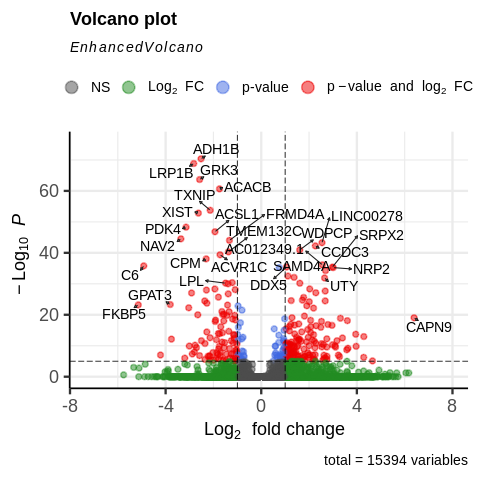

In [45]:
#12-2. Visualization via volcano plot (< 1min)
%%R
EnhancedVolcano(adipocyte_de,
                lab = rownames(adipocyte_de),
                x = 'avg_log2FC',
                y = 'p_val_adj',
                drawConnectors = TRUE)

Pathway analysis

In [47]:
#13-1. Create a ranking metric and sorting by descending order (< 1min)
%%R
adipocyte_de$ranking_metric <- sign(adipocyte_de$avg_log2FC) * (-log10(adipocyte_de$p_val_adj + 1e-300))
gene_list <- adipocyte_de$ranking_metric
names(gene_list) <- rownames(adipocyte_de)
gene_list <- sort(gene_list, decreasing = TRUE)

In [49]:
#13-2. Download Hallmark gene sets for Humans (1min)
%%R
h_df <- msigdbr(species = "Homo sapiens", category = "H") %>%
  dplyr::select(gs_name, gene_symbol)

 [100%] Downloaded 33730584 bytes...
In addition: Warning message:
The `category` argument of `msigdbr()` is deprecated as of msigdbr 10.0.0.
ℹ Please use the `collection` argument instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


In [60]:
#13-3. Run GSEA(<1min)
%%R
gsea_res <- GSEA(gene_list, TERM2GENE = h_df, pvalueCutoff = 0.2)

In addition: Warning message:
In fortify(object, showCategory = showCategory, split = split) :
  Arguments in `...` must be used.
✖ Problematic arguments:
• showCategory = showCategory
• split = split
ℹ Did you misspell an argument name?
using 'fgsea' for GSEA analysis, please cite Korotkevich et al (2019).

preparing geneSet collections...
GSEA analysis...
leading edge analysis...
done...
In addition: Warning message:
In preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam,  :
  There are ties in the preranked stats (0.01% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.


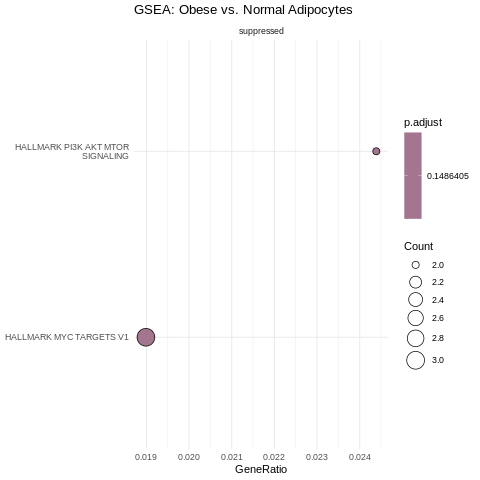

In [61]:
#13-4. Visualize GSEA result
%%R
dotplot(gsea_res, showCategory = 10, split = ".sign") +
  facet_grid(.~.sign) +
  theme_minimal() +
  labs(title = "GSEA: Obese vs. Normal Adipocytes")

Thank you for your time!